<a href="https://colab.research.google.com/github/Diggi14/project_Property2/blob/main/make_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!git clone https://github.com/Diggi14/project_Property2.git

Cloning into 'project_Property2'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (94/94), done.
Receiving objects: 100% (96/96), 5.61 MiB | 2.22 MiB/s, done.
remote: Total 96 (delta 51), reused 0 (delta 0), pack-reused 0 (from 0)
Resolving deltas: 100% (51/51), done.


In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [80]:
df=pd.read_csv('/content/project_Property2/cleaned_data3.csv')

In [81]:
df['FORMATTED_LANDMARK_DETAILS'][36]

"[{'category': 'MetroStation', 'text': '1 Metro Station', 'className': 'mstn', 'icon': 'https://static.99acres.com/universalapp/img/mstn.png'}, {'category': 'Shopping', 'text': '1 Shopping', 'className': 'shpng', 'icon': 'https://static.99acres.com/universalapp/img/shpng.png'}, {'category': 'Connectivity', 'text': '2 Connectivities', 'className': 'hw', 'icon': 'https://static.99acres.com/universalapp/img/hw.png'}, {'category': 'Education', 'text': '2 Educations', 'className': 'schl', 'icon': 'https://static.99acres.com/universalapp/img/schl.png'}, {'category': 'Airport', 'text': '1 Airport', 'className': 'aprt', 'icon': 'https://static.99acres.com/universalapp/img/aprt.png'}, {'category': 'Park', 'text': '1 Park', 'className': 'prk', 'icon': 'https://static.99acres.com/universalapp/img/prk.png'}, {'category': 'Club', 'text': '1 Club', 'className': 'clb', 'icon': 'https://static.99acres.com/universalapp/img/clb.png'}, {'category': 'Hotel', 'text': '1 Hotels', 'className': 'htl', 'icon':

In [82]:
import pandas as pd
import ast

def get_nearby_facilities(nearby_str):
    if pd.isna(nearby_str) or nearby_str == '[]' or nearby_str == '':
        return []

    try:
        facilities = ast.literal_eval(nearby_str)
        names = set()

        for f in facilities:
            cat = f.get('category', '').lower()
            text = f.get('text', '').lower()

            if 'metro' in cat:
                names.add('Metro')
            elif cat == 'education' or 'school' in text or 'college' in text:
                names.add('School/College')
            elif 'railway' in cat or 'railway' in text:
                names.add('Railway')
            elif 'airport' in cat:
                names.add('Airport')
            elif 'park' in cat:
                names.add('Park')
            elif 'hospital' in cat or 'hospital' in text:
                names.add('Hospital')
            elif 'bank' in cat or 'atm' in text or 'bank' in text:
                names.add('Bank/ATM')

        return list(names)

    except Exception as e:
        return []

df['nearby_facilities'] = df['FORMATTED_LANDMARK_DETAILS'].apply(get_nearby_facilities)


In [83]:
df.head(5)['nearby_facilities'][1]

['Railway', 'School/College', 'Metro', 'Hospital', 'Airport']

In [84]:
df.head(5)['FEATURES_LIST'][0]

"['Intercom Facility', 'Lift(s)', 'Water purifier', 'Maintenance Staff', 'Near Bank', 'Swimming Pool', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center']"

In [85]:
import pandas as pd
import ast

df['FEATURES_LIST'] = df['FEATURES_LIST'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) and x != '[]' else [])

In [86]:
df.drop(['FORMATTED_LANDMARK_DETAILS','BUILDING_NAME','TOP_USPS'],inplace=True,axis=1)

In [88]:
df.to_csv('recommender.csv',index=False)

In [87]:
df.head(4)

,PREFERENCE,PROPERTY_TYPE,BEDROOM_NUM,BATHROOM_NUM,BALCONY_NUM,PRICE_PER_UNIT_AREA,FURNISH,AGE,FLOOR_NUM,SUPERBUILTUP_SQFT,PRICE,SOCIETY_NAME,LOCALITY_WO_CITY,FEATURES_LIST,stories,nearby_facilities
0,S,Residential Apartment,4.0,4.0,4.0,8766.0,Semi-furnished,5-10,14.0,3434.0,2.63,Alpha Corp GurgaonOne 84,Sector 84,"[Intercom Facility, Lift(s), Water purifier, M...",single,"[Bank/ATM, Park, School/College, Hospital]"
1,S,Residential Apartment,4.0,4.0,3.0,21176.0,Semi-furnished,1-5,7.0,2870.0,3.60,DLF The Ultima,Sector 81,"[Security / Fire Alarm, Feng Shui / Vaastu Com...",single,"[Railway, School/College, Metro, Hospital, Air..."
2,S,Residential Apartment,3.0,3.0,3.0,13740.0,Semi-furnished,1-5,14.0,2802.0,3.85,Experion Windchants,Sector 112,"[Power Back-up, Feng Shui / Vaastu Compliant, ...",single,"[Railway, School/College, Hospital, Airport]"
3,S,Residential Apartment,3.0,4.0,4.0,8515.0,Semi-furnished,1-5,4.0,2290.0,1.95,ATS Triumph,Sector 104,"[Security / Fire Alarm, Power Back-up, Interco...",single,"[Park, Railway, School/College, Metro, Hospita..."


In [89]:
facility_types = ['School/College', 'Railway', 'Airport', 'Park', 'Hospital', 'Bank/ATM', 'Metro']

for facility in facility_types:
    df[facility] = df['nearby_facilities'].apply(lambda x: 1 if facility in x else 0)


In [90]:
df['total_facilities'] = df[['School/College', 'Railway', 'Airport', 'Park', 'Hospital', 'Bank/ATM', 'Metro']].sum(axis=1)


In [91]:
df.drop(['School/College','Railway','Airport','Park','Hospital','Bank/ATM','Metro'],inplace=True,axis=1)

In [95]:
all_facilities = set()

for facilities_list in df['FEATURES_LIST']:
    if isinstance(facilities_list, list):
        all_facilities.update(facilities_list)

unique_facilities = sorted(all_facilities)


In [96]:
df2=pd.DataFrame()
for facility in unique_facilities:
    df2[facility] = df['FEATURES_LIST'].apply(lambda x: 1 if facility in x else 0)


In [97]:
df2.head(4)

,Bank Attached Property,Centrally Air Conditioned,Club house / Community Center,Feng Shui / Vaastu Compliant,Fitness Centre / GYM,Intercom Facility,Lift(s),Maintenance Staff,Near Bank,Park,Piped-gas,Power Back-up,Private Garden / Terrace,Rain Water Harvesting,Security / Fire Alarm,Security Personnel,Shopping Centre,Swimming Pool,Visitor Parking,Waste Disposal,Water Storage,Water purifier
0,0,0,1,0,1,1,1,1,1,1,0,0,0,0,0,1,1,1,0,1,0,1
1,0,1,1,1,1,1,1,1,0,1,1,0,0,1,1,1,1,1,1,1,0,0
2,0,0,1,1,1,1,1,1,0,1,0,1,0,1,0,1,1,1,0,1,0,0
3,0,0,1,0,1,1,1,1,0,1,0,1,0,1,1,1,0,1,0,0,0,0


In [99]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scale_df=scaler.fit_transform(df2)

In [102]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(scale_df)
    wcss.append(kmeans.inertia_)

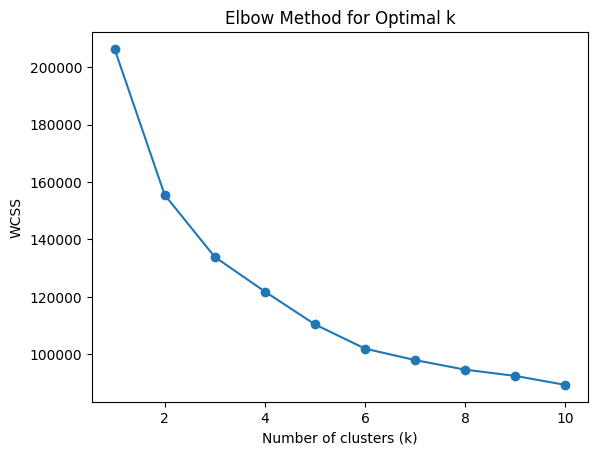

In [103]:
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()


In [111]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2,6):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    labels=kmeans.fit_predict(scale_df)
    score = silhouette_score(scale_df, labels)
    silhouette_scores.append(score)

In [112]:
silhouette_scores

[np.float64(0.24723872671144728),
 np.float64(0.21465722788797426),
 np.float64(0.20815312069610806),
 np.float64(0.22228542831583964)]

In [113]:
n=2
kmeans = KMeans(
    n_clusters=n,
    random_state=42,
)
kmeans.fit(scale_df)
cluster=kmeans.predict(scale_df)

In [120]:
df['furnishing_type']=cluster

In [121]:
df['furnishing_type'].value_counts() #0 is standard(better) and 1 is basic

,count
furnishing_type,
0,5481
1,3898


In [125]:
df.head(10)

,PREFERENCE,PROPERTY_TYPE,BEDROOM_NUM,BATHROOM_NUM,BALCONY_NUM,PRICE_PER_UNIT_AREA,FURNISH,AGE,FLOOR_NUM,SUPERBUILTUP_SQFT,PRICE,SOCIETY_NAME,LOCALITY_WO_CITY,FEATURES_LIST,stories,nearby_facilities,total_facilities,furnishing_type
0,S,Residential Apartment,4.0,4.0,4.0,8766.000000,Semi-furnished,5-10,14.0,3434.0,2.63,Alpha Corp GurgaonOne 84,Sector 84,"[Intercom Facility, Lift(s), Water purifier, M...",single,"[Bank/ATM, Park, School/College, Hospital]",4,0
1,S,Residential Apartment,4.0,4.0,3.0,21176.000000,Semi-furnished,1-5,7.0,2870.0,3.60,DLF The Ultima,Sector 81,"[Security / Fire Alarm, Feng Shui / Vaastu Com...",single,"[Railway, School/College, Metro, Hospital, Air...",5,0
2,S,Residential Apartment,3.0,3.0,3.0,13740.000000,Semi-furnished,1-5,14.0,2802.0,3.85,Experion Windchants,Sector 112,"[Power Back-up, Feng Shui / Vaastu Compliant, ...",single,"[Railway, School/College, Hospital, Airport]",4,0
3,S,Residential Apartment,3.0,4.0,4.0,8515.000000,Semi-furnished,1-5,4.0,2290.0,1.95,ATS Triumph,Sector 104,"[Security / Fire Alarm, Power Back-up, Interco...",single,"[Park, Railway, School/College, Metro, Hospita...",6,0
4,S,Residential Apartment,2.0,2.0,3.0,11571.000000,Unfurnished,0-1,12.0,1400.0,1.62,M3M Skywalk,Sector 74,"[Power Back-up, Intercom Facility, Lift(s), Sw...",single,"[Park, Railway, School/College, Metro, Hospita...",6,1
5,S,Independent/Builder Floor,3.0,3.0,3.0,8067.473414,Semi-furnished,1-5,0.0,2727.0,2.20,BPTP Amstoria,Sector 102,"[Feng Shui / Vaastu Compliant, Security / Fire...",single,"[Park, Railway, School/College, Hospital, Airp...",5,1
6,S,Residential Apartment,4.0,4.0,4.0,15463.000000,Semi-furnished,1-5,39.0,4850.0,7.50,Ireo Skyon,Sector 60,"[Water purifier, Security / Fire Alarm, Feng S...",single,"[Park, School/College, Metro, Hospital, Airport]",5,0
7,S,Residential Apartment,2.0,2.0,3.0,11428.000000,Unfurnished,0-1,16.0,1400.0,1.60,M3M Skywalk,Sector 74,"[Power Back-up, Intercom Facility, Lift(s), Pi...",single,"[Park, Railway, School/College, Metro, Hospita...",6,1
8,S,Residential Apartment,3.0,3.0,2.0,23648.000000,Semi-furnished,1-5,4.0,1950.0,3.50,Emaar MGF The Palm Drive,Sector 66,"[Water purifier, Security / Fire Alarm, Feng S...",single,"[Park, Railway, School/College, Metro, Hospita...",6,0
9,S,Residential Apartment,5.0,5.0,4.0,11597.000000,Semi-furnished,1-5,14.0,3880.0,4.50,Indiabulls Enigma,Sector 110,"[Power Back-up, Security / Fire Alarm, Interco...",single,"[Park, Railway, School/College, Metro, Hospita...",6,1


In [126]:
df.to_csv('cleaned_data4.csv')